# "THE PRICE IS RIGHT" Capstone Project

This week - build a model that predicts how much something costs from a description, based on a scrape of Amazon data


A model that can estimate how much something costs, from its description.

# Order of play

DAY 1: Data Curation  
DAY 2: Data Pre-processing  
DAY 3: Evaluation, Baselines, Traditional ML  
DAY 4: Deep Learning and LLMs  
DAY 5: Fine-tuning a Frontier Model  

## DAY 4: Neural Networks and LLMs

Today we'll work from Traditional ML to Neural Networks to Large Language Models!!

In [1]:
# imports

import os
from dotenv import load_dotenv
from huggingface_hub import login
from pricer.evaluator import evaluate
from litellm import completion
from pricer.items import Item
import numpy as np
from tqdm.notebook import tqdm
import csv
from sklearn.feature_extraction.text import HashingVectorizer
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from torch.optim.lr_scheduler import CosineAnnealingLR


In [2]:
LITE_MODE = True

load_dotenv(override=True)
hf_token = os.environ['HF_TOKEN']
login(hf_token, add_to_git_credential=True)

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


In [3]:
username = "ed-donner"
dataset = f"{username}/items_lite" if LITE_MODE else f"{username}/items_full"

train, val, test = Item.from_hub(dataset)

print(f"Loaded {len(train):,} training items, {len(val):,} validation items, {len(test):,} test items")

Loaded 20,000 training items, 1,000 validation items, 1,000 test items


# Before we look at the Artificial Neural Networks

## There is a different kind of Neural Network we could consider

In [4]:
# Write the test set to a CSV

with open('human_in.csv', 'w', encoding="utf-8") as csvfile:
    writer = csv.writer(csvfile)
    for t in test[:100]:
        writer.writerow([t.summary, 0])

In [5]:
# Read it back in

human_predictions = []
with open('human_out.csv', 'r', encoding="utf-8") as csvfile:
    reader = csv.reader(csvfile)
    for row in reader:
        human_predictions.append(float(row[1]))

In [6]:
def human_pricer(item):
    idx = test.index(item)
    return human_predictions[idx]

In [7]:
human = human_pricer(test[0])
actual = test[0].price
print(f"Human predicted {human} for an item that actually costs {actual}")


Human predicted 120.0 for an item that actually costs 219.0


  0%|          | 0/100 [00:00<?, ?it/s]

$99 $184 $12 $15 $18 $10 $119 $135 $6 $270 $643 $329 $15 $26 $24 $18 $29 $25 $25 $53 $35 $126 $25 $127 $273 $398 $55 $6 $101 $51 $30 $5 $35 $9 $10 $419 $25 $11 $186 $33 $161 $51 $23 $155 $150 $4 $31 $18 $115 $82 $25 $111 $410 $75 $67 $34 $8 $10 $122 $28 $116 $17 $19 $60 $599 $60 $160 $355 $75 $34 $17 $2 $70 $76 $41 $9 $226 $5 $5 $4 $0 $7 $5 $74 $7 $10 $68 $74 $5 $3 $17 $45 $5 $16 $0 $153 $2 $122 $150 $355 

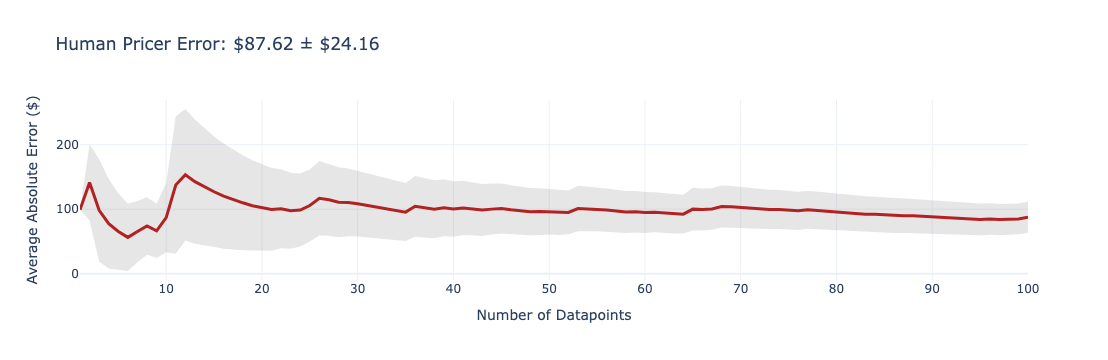

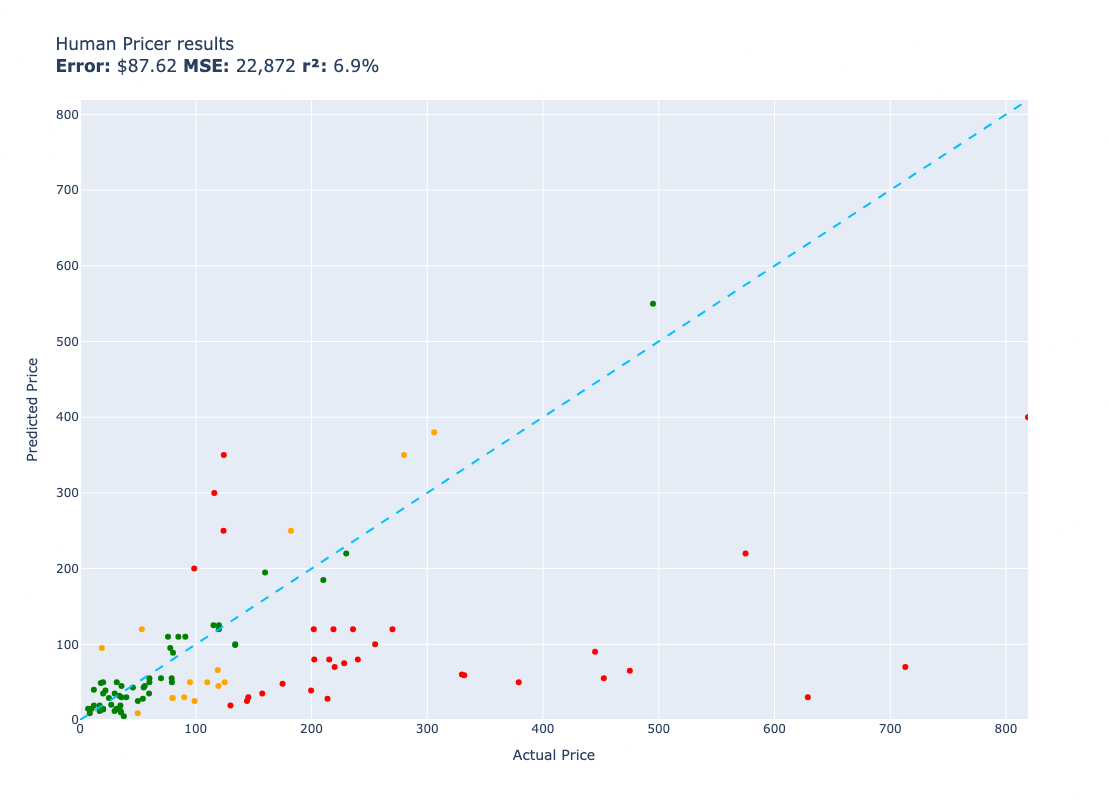

In [8]:
evaluate(human_pricer, test, size=100)

# And now - a vanilla Neural Network

During the remainder of this course we will get deeper into how Neural Networks work, and how to train a neural network.

This is just a sneak preview - let's make our own Neural Network, from scratch, using Pytorch.

Use this to get intuition; it's not important to know all about Neural networks at this point..

In [9]:
# Prepare our documents and prices

y = np.array([float(item.price) for item in train])
documents = [item.summary for item in train]

In [10]:
# Use the HashingVectorizer for a Bag of Words model
# Using binary=True with the CountVectorizer makes "one-hot vectors"

np.random.seed(42)
vectorizer = HashingVectorizer(n_features=5000, stop_words='english', binary=True)
X = vectorizer.fit_transform(documents)

In [11]:
# Define the neural network - here is Pytorch code to create a 8 layer neural network

class NeuralNetwork(nn.Module):
    def __init__(self, input_size):
        super(NeuralNetwork, self).__init__()
        self.layer1 = nn.Linear(input_size, 128)
        self.layer2 = nn.Linear(128, 64)
        self.layer3 = nn.Linear(64, 64)
        self.layer4 = nn.Linear(64, 64)
        self.layer5 = nn.Linear(64, 64)
        self.layer6 = nn.Linear(64, 64)
        self.layer7 = nn.Linear(64, 64)
        self.layer8 = nn.Linear(64, 1)
        self.relu = nn.ReLU()

    def forward(self, x):
        output1 = self.relu(self.layer1(x))
        output2 = self.relu(self.layer2(output1))
        output3 = self.relu(self.layer3(output2))
        output4 = self.relu(self.layer4(output3))
        output5 = self.relu(self.layer5(output4))
        output6 = self.relu(self.layer6(output5))
        output7 = self.relu(self.layer7(output6))
        output8 = self.layer8(output7)
        return output8

In [12]:
# Convert data to PyTorch tensors
X_train_tensor = torch.FloatTensor(X.toarray())
y_train_tensor = torch.FloatTensor(y).unsqueeze(1)

# Split the data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X_train_tensor, y_train_tensor, test_size=0.01, random_state=42)

# Create the loader
train_dataset = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

# Initialize the model
input_size = X_train_tensor.shape[1]
model = NeuralNetwork(input_size)

In [13]:
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Number of trainable parameters: {trainable_params:,}")

Number of trainable parameters: 669,249


In [25]:
# Define loss function and optimizer

loss_function = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# We will do 2 complete runs through the data

EPOCHS = 2

for epoch in range(EPOCHS):
    model.train()
    for batch_X, batch_y in tqdm(train_loader):
        optimizer.zero_grad()

        # The next 4 lines are the 4 stages of training: forward pass, loss calculation, backward pass, optimize
        
        outputs = model(batch_X) # Step 1: Forward Pass
        loss = loss_function(outputs, batch_y) # Step 2: Loss Calculation
        loss.backward() # Step 3: Backward Pass
        optimizer.step() # Step 4: Optimize

    model.eval()
    with torch.no_grad():
        val_outputs = model(X_val)
        val_loss = loss_function(val_outputs, y_val)

    print(f'Epoch [{epoch+1}/{EPOCHS}], Train Loss: {loss.item():.3f}, Val Loss: {val_loss.item():.3f}')

  0%|          | 0/310 [00:00<?, ?it/s]

Epoch [1/2], Train Loss: 243.422, Val Loss: 19086.053


  0%|          | 0/310 [00:00<?, ?it/s]

Epoch [2/2], Train Loss: 533.853, Val Loss: 17322.186


In [26]:
def neural_network(item):
    model.eval()
    with torch.no_grad():
        vector = vectorizer.transform([item.summary])
        vector = torch.FloatTensor(vector.toarray())
        result = model(vector)[0].item()
    return max(0, result)

  0%|          | 0/200 [00:00<?, ?it/s]

$149 $33 $30 $17 $53 $195 $14 $82 $2 $105 $359 $254 $47 $427 $26 $9 $17 $27 $124 $72 $107 $61 $174 $86 $202 $211 $380 $109 $5 $62 $6 $61 $98 $55 $102 $28 $10 $46 $78 $54 $179 $6 $39 $77 $90 $2 $128 $49 $29 $75 $15 $70 $73 $18 $126 $143 $52 $191 $57 $24 $96 $43 $55 $15 $490 $108 $55 $190 $76 $313 $12 $21 $130 $35 $1 $46 $13 $12 $8 $2 $79 $80 $36 $68 $84 $122 $106 $167 $25 $94 $83 $57 $2 $9 $46 $3 $51 $158 $148 $174 $19 $55 $10 $97 $72 $68 $114 $340 $7 $81 $41 $40 $31 $34 $39 $213 $271 $212 $4 $43 $19 $182 $165 $69 $104 $135 $13 $86 $24 $104 $19 $60 $97 $10 $97 $6 $51 $18 $84 $85 $1 $86 $52 $298 $145 $99 $7 $293 $172 $8 $3 $72 $14 $57 $4 $133 $143 $23 $37 $19 $172 $41 $20 $13 $297 $2 $32 $30 $4 $92 $78 $43 $8 $0 $22 $29 $11 $39 $66 $33 $212 $33 $240 $173 $43 $20 $73 $38 $14 $1 $147 $76 $6 $70 $23 $19 $5 $111 $59 $55 

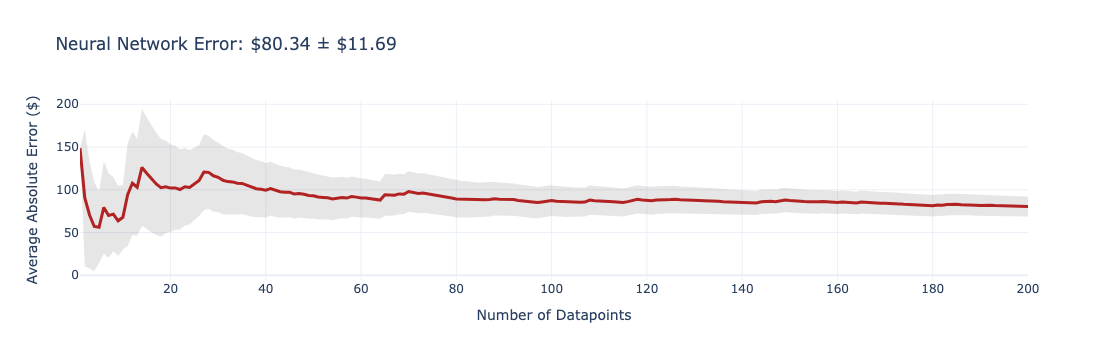

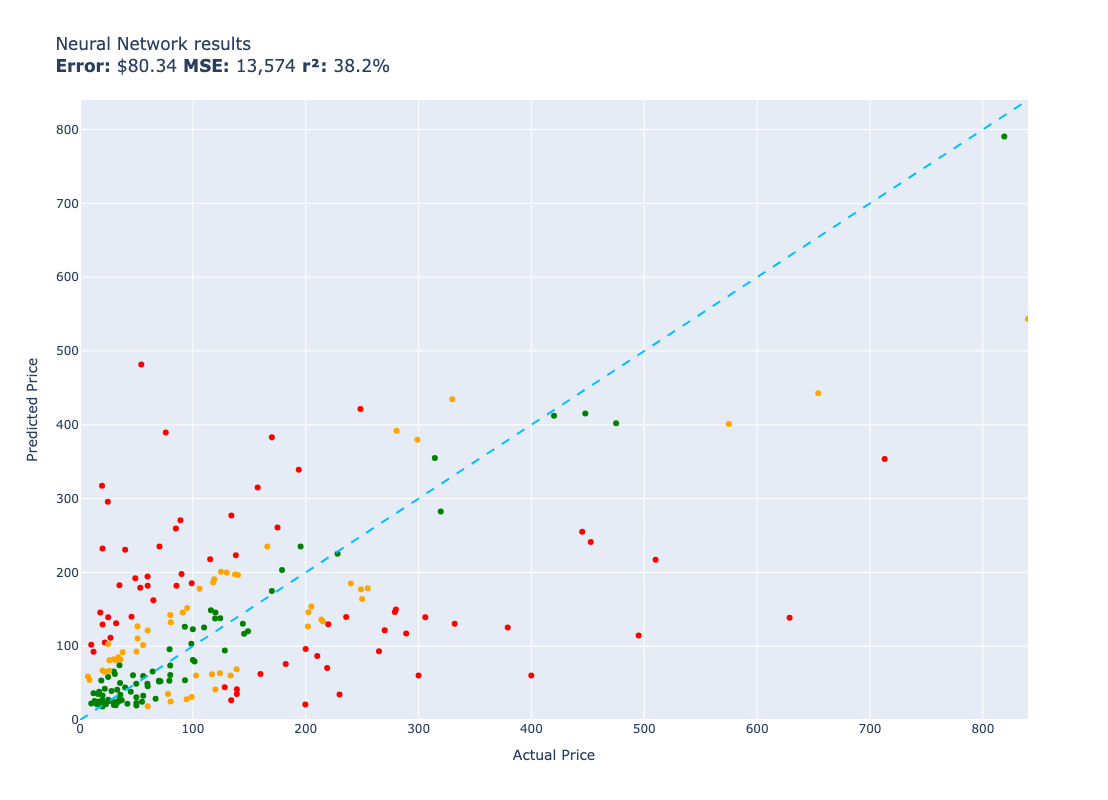

In [27]:
evaluate(neural_network, test)

# And now - to the frontier!

Let's see how Frontier models do out of the box; no training, just inference based on their world knowledge.

Tomorrow we will do some training.

In [28]:
def messages_for(item):
    message = f"Estimate the price of this product. Respond with the price, no explanation\n\n{item.summary}"
    return [{"role": "user", "content": message}]

In [18]:
print(test[0].summary)

Title: Excess V2 Distortion/Modulation Pedal  
Category: Music Pedals  
Brand: Old Blood Noise  
Description: A versatile pedal offering distortion and three modulation modes—delay, chorus, and harmonized fifths—with full control over signal routing and expression.  
Details: Features include separate gain, tone, and volume controls; time, depth, and volume per modulation; order switching, soft‑touch bypass, and expression jack for dynamic control.


In [19]:
messages_for(test[0])

[{'role': 'user',
  'content': 'Estimate the price of this product. Respond with the price, no explanation\n\nTitle: Excess V2 Distortion/Modulation Pedal  \nCategory: Music Pedals  \nBrand: Old Blood Noise  \nDescription: A versatile pedal offering distortion and three modulation modes—delay, chorus, and harmonized fifths—with full control over signal routing and expression.  \nDetails: Features include separate gain, tone, and volume controls; time, depth, and volume per modulation; order switching, soft‑touch bypass, and expression jack for dynamic control.'}]

In [20]:
# The function for gpt-4.1-nano

def gpt_4__1_nano(item):
    response = completion(model="openai/gpt-4.1-nano", messages=messages_for(item))
    return response.choices[0].message.content

In [21]:
gpt_4__1_nano(test[0])

'$200'

In [ ]:
test[0].price

In [ ]:
evaluate(gpt_4__1_nano, test)

In [ ]:
def claude_opus_4_5(item):
    response = completion(model="anthropic/claude-opus-4-5", messages=messages_for(item))
    return response.choices[0].message.content

In [ ]:
evaluate(claude_opus_4_5, test)

In [ ]:
def gemini_3_pro_preview(item):
    response = completion(model="gemini/gemini-3-pro-preview", messages=messages_for(item), reasoning_effort='low')
    return response.choices[0].message.content

In [ ]:
evaluate(gemini_3_pro_preview, test, size=50, workers=2)

In [ ]:
def gemini_2__5_flash_lite(item):
    response = completion(model="gemini/gemini-2.5-flash-lite", messages=messages_for(item))
    return response.choices[0].message.content

In [ ]:
evaluate(gemini_2__5_flash_lite, test)

In [ ]:

def grok_4__1_fast(item):
    response = completion(model="xai/grok-4-1-fast-non-reasoning", messages=messages_for(item), seed=42)
    return response.choices[0].message.content

In [ ]:
evaluate(grok_4__1_fast, test)

In [ ]:
# The function for gpt-5.1

def gpt_5__1(item):
    response = completion(model="gpt-5.1", messages=messages_for(item), reasoning_effort='high', seed=42)
    return response.choices[0].message.content


In [ ]:
evaluate(gpt_5__1, test)